## Batch Size Sweep: 3 Mediums

Qdrant Memory:  (128, 16592.81425638905)
Qdrant Memory:  (128, 16552.054907314126)
Qdrant Lustre:  (131072, 10277.079594988369)
Qdrant Lustre:  (128, 465.123010874602)
Milvus Memory:  (2048, 9396.625314211253)
Milvus Memory:  (2048, 9394.514323513817)
Milvus lustre:  (4096, 8812.639501967607)
Milvus lustre:  (4096, 8780.018616410409)
Milvus DAOS:  (16384, 6430.931618516192)
Milvus DAOS:  (16384, 6382.830557870375)


## Multi-Client-One-Worker

In [1]:
import os
import re
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
# Regex to capture ONLY the number directly after "bs_"

def extract(target_string, target_dir):

    
    pattern = re.compile(target_string + r"(\d+)")
    # print(os.listdir(f"{target_dir}"))
    dirs = [
        d for d in os.listdir(f"{target_dir}")
        if target_string in d
    ]
    # print(dirs)
    def sort_key(name):
        match = pattern.search(name)
        if match:
            return int(match.group(1))  # sort numerically
        return float("inf")  # put non-matching names at the end
    
    sorted_dirs = sorted(dirs, key=sort_key)
    
    labels = []
    op_heights = []
    prep_heights = []   # stacked bottom
    upload_heights = [] # stacked top
    # print("Filtered + sorted directories:")
    single_means = []
    op_means = []

    for d in sorted_dirs:
        
        # print(d)
        match = pattern.search(d)
        # print(d)
        bs = int(match.group(1))
        # print(bs)
        # find a CSV file in the directory (adjust if you have a specific name)
        csv_files = glob.glob(os.path.join(target_dir,d, "summary.csv"))
        if not csv_files:
            continue  # skip if no CSV
        csv_path = csv_files[0]
        # print(bs)
        df = pd.read_csv(csv_path)
    
        # print(d)
        # Expect operations: "prep", "upload", "op"
        if "network" in d:
            target_rank = "0"
            # single_prep_row = df[(df["operation"] == "prep")].iloc[0]
            # single_upload_row = df[(df["operation"] == "upload")].iloc[0]
            op_row = df[(df["operation"] == "op")].iloc[0]
            vps = op_row["v/s"]
        else:
            # print(d, df)
            target_rank = "0"
            single_prep_row = df[(df["operation"] == "prep") & (df["rank"] == target_rank)].iloc[0]
            single_upload_row = df[(df["operation"] == "upload") & (df["rank"] == target_rank)].iloc[0]
            single_op_row = df[(df["operation"] == "op") & (df["rank"] == target_rank)].iloc[0]
            single_vps = single_op_row["rank_v/s"]
            single_means.append(single_vps)

            target_rank = "all"
            prep_row = df[(df["operation"] == "prep") & (df["rank"] == target_rank)].iloc[0]
            upload_row = df[(df["operation"] == "upload") & (df["rank"] == target_rank)].iloc[0]
            op_row = df[(df["operation"] == "op") & (df["rank"] == target_rank)].iloc[0]

    
            # vectors per second for the whole operation
            vps = op_row["rank_v/s"]
        
       
    
        labels.append(bs)
        op_heights.append(vps)
        op_means.append(op_row['mean'])
        # prep_heights.append(prep_part)
        # upload_heights.append(upload_part)
    return labels, op_heights, single_means, op_means

def extract_max(bs, lst):
    idx = lst.index(max(lst))
    return bs[idx], max(lst)


A_milvus = []    
bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/milvus/memoryWP/")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("1:", extract_max(bs,A_milvusMemory))

bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C2_uploadBS","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvusWP/wpBatchSweep2")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("2:", extract_max(bs,A_milvusMemory))

bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C4_uploadBS","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvusWP/wpBatchSweep4")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("4:", extract_max(bs,A_milvusMemory))

bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C8_uploadBS","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvusWP/wpBatchSweep8")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("8:", extract_max(bs,A_milvusMemory))

bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C16_uploadBS","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvusWP/wpBatchSweep16")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("16:", extract_max(bs,A_milvusMemory))

bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C32_uploadBS","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvusWP/wpBatchSweep32")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])
print("32:", extract_max(bs,A_milvusMemory))


A_milvusMemory

1: (8192, 8758.135783472659)
2: (4096, 15454.31450455342)
4: (1024, 28562.15904234181)
8: (128, 43865.16396978664)
16: (128, 45598.75376399214)
32: (128, 47236.76930557693)


[37434.2511800796,
 42257.36617892081,
 47236.76930557693,
 44783.59585534622,
 41054.0679895961,
 33532.71921879171,
 30364.388303141972]

In [2]:
import os
import re
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt


def extract(target_string, target_dir):

    
    pattern = re.compile(target_string + r"(\d+)")
    # print(os.listdir(f"{target_dir}"))
    dirs = [
        d for d in os.listdir(f"{target_dir}")
        if target_string in d
    ]

    def sort_key(name):
        match = pattern.search(name)
        if match:
            return int(match.group(1))  # sort numerically
        return float("inf")  # put non-matching names at the end
    
    sorted_dirs = sorted(dirs, key=sort_key)
    
    labels = []
    op_heights = []
    prep_heights = []   # stacked bottom
    upload_heights = [] # stacked top
  

    for d in sorted_dirs:
       
        match = pattern.search(d)
        print(d)
        bs = int(match.group(1))
        # print(bs)
        # find a CSV file in the directory (adjust if you have a specific name)
        csv_files = glob.glob(os.path.join(target_dir,d, "summary.csv"))
        if not csv_files:
            continue  # skip if no CSV
        csv_path = csv_files[0]
    
        df = pd.read_csv(csv_path)
        # print(bs)

        if bs == 1 and "memory" not in d:
      
            op_row = df[df["operation"] == "op"].iloc[0]
        
            # vectors per second for the whole operation
            vps = op_row["v/s"]
        
            labels.append(bs)
            op_heights.append(vps)
        else:
            op_row = df[(df["operation"] == "op") & (df["rank"] == "all")].iloc[0]
            # vectors per second for the whole operation
            vps = op_row["rank_v/s"]
        
            labels.append(bs)
            op_heights.append(vps)
            
        # prep_heights.append(prep_part)
        # upload_heights.append(upload_part)
    return labels, op_heights
# bs, P_milvusGo = extract("networkTesting_go_bs_2048_c_","./polaris/insert/multiClient/milvusGo/")
# # bs, P_milvusPython = extract("networkTesting_mpInsert_bs_2048_c_", "./multiClient/milvusPython/")
# bs, P_qdrantRust = extract("network_qRustCli_1_","./polaris/insert/multiClient/qdrantRust/")
# # _, P_qdrantPython = extract("network_mpUpload_1_","./multiClient/qdrantPython/")

# bs, A_milvusGo = extract("insert_memory_N1_NP1_C","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/milvus/")
bs, A_qdrantRust = extract("insert_memory_N1_NP1_C","./aurora/insert/storageMediumTesting/multiClientSingleWorker/memory/qdrant/")
# qdrantPython = qdrantPython + [0]

# milvusPython = [6999.936617280763] + milvusPython

insert_memory_N1_NP1_C1_uploadBS128_2026-02-12_22_48_15
insert_memory_N1_NP1_C2_uploadBS128_2026-02-13_00_09_49
insert_memory_N1_NP1_C4_uploadBS128_2026-02-13_00_10_06
insert_memory_N1_NP1_C8_uploadBS128_2026-02-13_00_11_15
insert_memory_N1_NP1_C16_uploadBS128_2026-02-13_00_12_48
insert_memory_N1_NP1_C32_uploadBS128_2026-02-13_00_13_41


In [4]:
A_qdrantRust

[16552.054907314126,
 29981.74831776365,
 37219.44590555516,
 36973.9195158019,
 36201.479454304426,
 36390.535448538285]

In [4]:
import csv

def read_ordered_by_clients(path):
    data = []

    with open(path, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].startswith("#"):
                continue
            clients = int(row[0])
            value = float(row[1])
            data.append((clients, value))

    # sort by client count
    data.sort(key=lambda x: x[0])

    # return just values in sorted order
    return [v for _, v in data]


A_weaviate = read_ordered_by_clients("./SongResults/aurora/fig3_weaviate.csv")

In [5]:
A_weaviate

[5037.216487, 7842.822589, 9985.492198, 10269.6142, 11277.95158, 11202.41028]

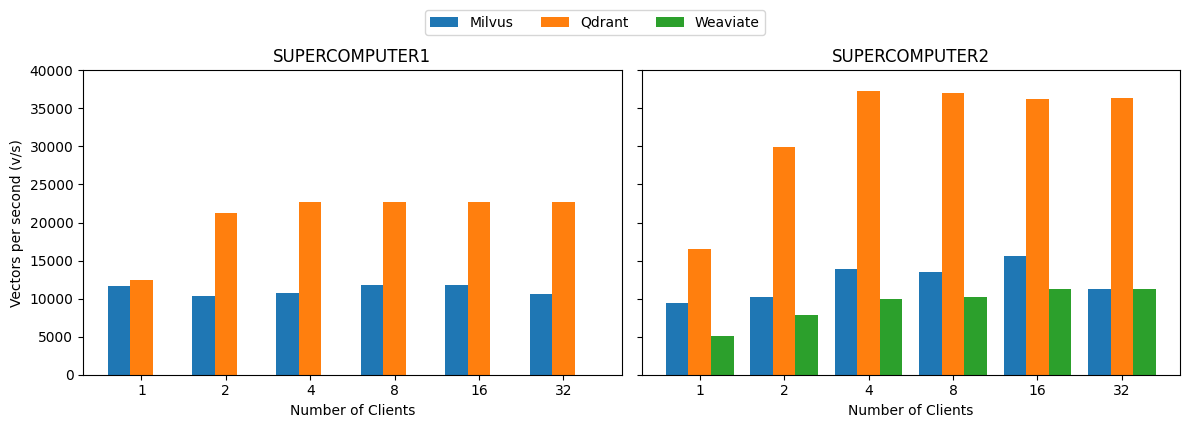

In [19]:
import matplotlib.pyplot as plt
import numpy as np

slide = 5
x = np.arange(len(bs))

total_width = 0.8
max_bars = 3
bar_width = total_width / max_bars

offsets = [
    -1.0 * bar_width,
     0.0 * bar_width,
     1.0 * bar_width,
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

systems = [
    ("SUPERCOMPUTER1", P_milvusGo, P_qdrantRust, [0 for _ in range(len(bs))]),
    ("SUPERCOMPUTER2",
     A_milvusGo,
     A_qdrantRust,
     A_weaviate),
]

for ax, (title, milvus_i, qdrant_i, weaviate_i) in zip(axes, systems):
    ax.set_ylim(0, 40000)

    if slide == 1:
        ax.bar(x + offsets[0], [0]*len(bs), bar_width, label='Milvus')
        ax.bar(x + offsets[1], [0]*len(bs), bar_width, label='Qdrant')
        ax.bar(x + offsets[2], [0]*len(bs), bar_width, label='Weaviate')

    if slide == 5:
        ax.bar(x + offsets[0], milvus_i, bar_width, label='Milvus')
        ax.bar(x + offsets[1], qdrant_i, bar_width, label='Qdrant')
        ax.bar(x + offsets[2], weaviate_i, bar_width, label='Weaviate')

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e}' for e in bs])
    ax.set_xlabel('Number of Clients')

axes[0].set_ylabel('Vectors per second (v/s)')

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.075))

plt.tight_layout()
plt.savefig("insertTesting.pdf", format="pdf", bbox_inches="tight")
plt.show()


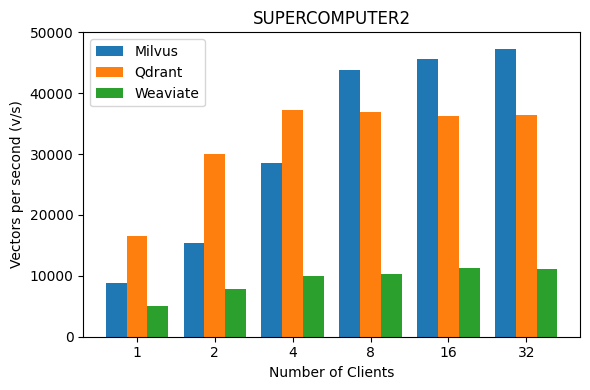

In [48]:
import matplotlib.pyplot as plt
import numpy as np

slide = 5
x = np.arange(len(bs))

total_width = 0.8
max_bars = 3
bar_width = total_width / max_bars

offsets = [
    -1.0 * bar_width,
     0.0 * bar_width,
     1.0 * bar_width,
]

# Only SUPERCOMPUTER2
title = "SUPERCOMPUTER2"
milvus_i = A_milvus
qdrant_i = A_qdrantRust
weaviate_i = A_weaviate

fig, ax = plt.subplots(figsize=(6, 4))

ax.set_ylim(0, 50000)

if slide == 1:
    ax.bar(x + offsets[0], [0]*len(bs), bar_width, label='Milvus')
    ax.bar(x + offsets[1], [0]*len(bs), bar_width, label='Qdrant')
    ax.bar(x + offsets[2], [0]*len(bs), bar_width, label='Weaviate')

if slide == 5:
    ax.bar(x + offsets[0], milvus_i, bar_width, label='Milvus')
    ax.bar(x + offsets[1], qdrant_i, bar_width, label='Qdrant')
    ax.bar(x + offsets[2], weaviate_i, bar_width, label='Weaviate')

ax.set_title(title)
ax.set_xticks(x)
ax.set_xticklabels([f'{e}' for e in bs])
ax.set_xlabel('Number of Clients')
ax.set_ylabel('Vectors per second (v/s)')

ax.legend()
# ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.savefig("insertTesting.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [41]:
len(bs)

7

### Medium Testing (Batch Sweep)

In [1]:
import os
import re
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
# Regex to capture ONLY the number directly after "bs_"

def extract(target_string, target_dir):

    
    pattern = re.compile(target_string + r"(\d+)")
    # print(os.listdir(f"{target_dir}"))
    dirs = [
        d for d in os.listdir(f"{target_dir}")
        if target_string in d
    ]
    # print(dirs)
    def sort_key(name):
        match = pattern.search(name)
        if match:
            return int(match.group(1))  # sort numerically
        return float("inf")  # put non-matching names at the end
    
    sorted_dirs = sorted(dirs, key=sort_key)
    
    labels = []
    op_heights = []
    prep_heights = []   # stacked bottom
    upload_heights = [] # stacked top
    # print("Filtered + sorted directories:")
    single_means = []
    op_means = []

    for d in sorted_dirs:
        
        # print(d)
        match = pattern.search(d)
        # print(d)
        bs = int(match.group(1))
        # print(bs)
        # find a CSV file in the directory (adjust if you have a specific name)
        csv_files = glob.glob(os.path.join(target_dir,d, "summary.csv"))
        if not csv_files:
            continue  # skip if no CSV
        csv_path = csv_files[0]
        # print(bs)
        df = pd.read_csv(csv_path)
    
        # print(d)
        # Expect operations: "prep", "upload", "op"
        if "network" in d:
            target_rank = "0"
            # single_prep_row = df[(df["operation"] == "prep")].iloc[0]
            # single_upload_row = df[(df["operation"] == "upload")].iloc[0]
            op_row = df[(df["operation"] == "op")].iloc[0]
            vps = op_row["v/s"]
        else:
            # print(d, df)
            target_rank = "0"
            single_prep_row = df[(df["operation"] == "prep") & (df["rank"] == target_rank)].iloc[0]
            single_upload_row = df[(df["operation"] == "upload") & (df["rank"] == target_rank)].iloc[0]
            single_op_row = df[(df["operation"] == "op") & (df["rank"] == target_rank)].iloc[0]
            single_vps = single_op_row["rank_v/s"]
            single_means.append(single_vps)

            target_rank = "all"
            prep_row = df[(df["operation"] == "prep") & (df["rank"] == target_rank)].iloc[0]
            upload_row = df[(df["operation"] == "upload") & (df["rank"] == target_rank)].iloc[0]
            op_row = df[(df["operation"] == "op") & (df["rank"] == target_rank)].iloc[0]

    
            # vectors per second for the whole operation
            vps = op_row["rank_v/s"]
        
       
    
        labels.append(bs)
        op_heights.append(vps)
        op_means.append(op_row['mean'])
        # prep_heights.append(prep_part)
        # upload_heights.append(upload_part)
    return labels, op_heights, single_means, op_means

def extract_max(bs, lst):
    idx = lst.index(max(lst))
    return bs[idx], max(lst)

A_qdrant = []    
bs, A_qdrantMemory, qdrantPythonRecv, qdrant_meansPython = extract("insert_memory_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/qdrant/memory/")
A_qdrant.append(extract_max(bs,A_qdrantMemory)[1])
A_qdrant.append(0) # DAOS does not work
bs, A_qdrantLustre, qdrantPythonRecv, qdrant_meansPython = extract("insert_lustre_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/qdrant/lustre/")
A_qdrant.append(extract_max(bs,A_qdrantLustre)[1])

# ### 
# u
A_milvus = []    
bs, A_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/milvus/memoryWP/")
A_milvus.append(extract_max(bs,A_milvusMemory)[1])

# u
bs, A_milvusDAOS, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_DAOS_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/milvus/daosWP/")
A_milvus.append(extract_max(bs,A_milvusDAOS)[1])

# u
bs, A_milvusLustre, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_lustre_N1_NP1_C1_uploadBS","./aurora/insert/storageMediumTesting/batchSweep/milvus/lustreWP/")
A_milvus.append(extract_max(bs,A_milvusLustre)[1])


P_milvus = []    
bs, P_milvusMemory, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_memory_N1_NP1_C1_uploadBS","./polaris/insert/mediumTesting/milvus/memorySweep/")
P_milvus.append(extract_max(bs,P_milvusMemory)[1])

bs, P_milvusSSD, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_SSD_N1_NP1_C1_uploadBS","./polaris/insert/mediumTesting/milvus/SSDSweep")
P_milvus.append(extract_max(bs,P_milvusSSD)[1])

bs, P_milvuslustre, milvusPythonRecv, milvus_meansPython = extract("insert_STANDALONE_lustre_N1_NP1_C1_uploadBS","./polaris/insert/mediumTesting/milvus/lustreSweep/")
P_milvus.append(extract_max(bs,P_milvuslustre)[1])
### 

P_qdrant = []    
bs, P_qdrantMemory, qdrantPythonRecv, qdrant_meansPython = extract("insert_memory_N1_NP1_C1_uploadBS","./polaris/insert/mediumTesting/qdrant/memory/")
P_qdrant.append(extract_max(bs,P_qdrantMemory)[1])

bs, P_qdrantSSD, qdrantPythonRecv, qdrant_meansPython = extract("network_qRustCli_1_1_bs_","./polaris/insert/singleClient/qdrantRust/")
P_qdrant.append(extract_max(bs,P_qdrantSSD)[1])

bs, P_qdrantLustre, qdrantPythonRecv, qdrant_meansPython = extract("insert_lustre_N1_NP1_C1_uploadBS","./polaris/insert/mediumTesting/qdrant/lustre/")
P_qdrant.append(extract_max(bs,P_qdrantLustre)[1])



In [60]:
print("Aurora-memory: ", extract_max( bs,A_milvusMemory))
print("Aurora=lustre: ",extract_max( bs,A_milvusLustre))
print("Polaris: ",extract_max( bs,P_milvusMemory))


print(extract_max(bs,A_qdrantLustre))

Aurora-memory:  (512, 8758.135783472659)
Aurora=lustre:  (512, 5381.201113515564)
Polaris:  (256, 14517.649751117744)
(128, 465.123010874602)


In [2]:
import csv

def read_ordered_values(path):
    order = ["memory", "daos", "lustre"]
    values = {}

    with open(path, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or len(row) < 2:
                continue
            name = row[0].strip().lower()
            value = float(row[1])
            values[name] = value

    return [values[o] for o in order]
A_weaviate = read_ordered_values("./SongResults/aurora/fig5_weaviate.csv")

In [11]:
print(extract_max(bs,A_milvusDAOS))
print(A_milvusDAOS)
print(A_milvusLustre)
print(extract_max(bs,A_milvusLustre))

(128, 6382.830557870375)
[3649.767025541056, 3788.495865943213, 3870.677546413872, 3890.957540531154, 3922.906189961937, 5245.3511936127725, 4053.9137975255, 6382.830557870375, 4381.463290518483]
[900.7843649392858, 1619.3199643101184, 2257.5268481414587, 3655.1471763398863, 4878.487324419241, 6163.696052153271, 7066.607467021102, 4415.983697327507, 7468.643301802783, 8130.163867742095, 8380.830218643821, 8652.992281413342, 8650.623076426351, 8780.018616410409, 8670.500525345167, 7614.766760097363, 7733.574817534751]
(8192, 8780.018616410409)


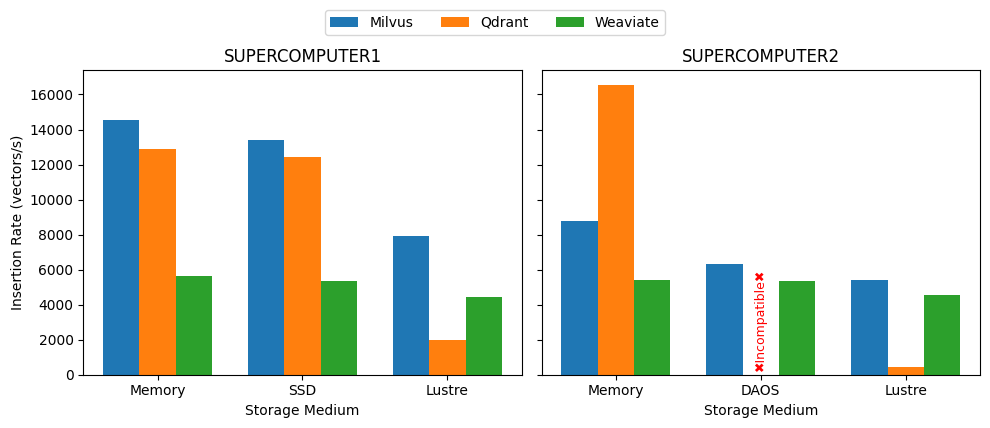

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Storage media per system
storage_sc1 = ["Memory", "SSD", "Lustre"]
storage_sc2 = ["Memory", "DAOS", "Lustre"]

# X positions
x1 = np.arange(len(storage_sc1))
x2 = np.arange(len(storage_sc2))

bar_width = 0.25

# Placeholder data (all zeros)
# SUPERCOMPUTER1 (Memory, SSD, Lustre)
qdrant_sc1   = P_qdrant
milvus_sc1   = P_milvus
weaviate_sc1 = [5628.220962 ,5376.251065, 4430.877059]

# SUPERCOMPUTER2 (Memory, DAOS, Lustre)
qdrant_sc2   = A_qdrant
milvus_sc2   = A_milvus
weaviate_sc2 = A_weaviate

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

systems = [
    ("SUPERCOMPUTER1", storage_sc1, x1, qdrant_sc1, milvus_sc1, weaviate_sc1),
    ("SUPERCOMPUTER2", storage_sc2, x2, qdrant_sc2, milvus_sc2, weaviate_sc2),
]

for ax, (title, storage, x, qdrant, milvus, weaviate) in zip(axes, systems):
    ax.bar(x - bar_width,             milvus,   bar_width, label="Milvus")
    ax.bar(x, qdrant,   bar_width, label="Qdrant")
    ax.bar(x + bar_width, weaviate, bar_width, label="Weaviate")

    ax.set_xticks(x)
    ax.set_xticklabels(storage)
    ax.set_xlabel("Storage Medium")
    ax.set_title(title)
axes[0].set_ylabel("Insertion Rate (vectors/s)")

ax2 = axes[1]
daos_index = 1
x_position = x2[daos_index] 


ymax = ax2.get_ylim()[1]
# Vertical label aligned like a bar
ax2.text(
    x_position,
    ymax * 0.179,
    "✖Incompatible✖",
    color="red",
    fontsize=9,
    ha="center",
    va="center",
    rotation=90,   # <-- This rotates it vertically
)



# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.075))

plt.tight_layout()
plt.savefig("insertitonMediumTesting.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Insert Scaling

In [43]:
import os
import re
import glob
import pandas as pd

def extract(target_string, target_dir):
    """
    Returns:
      labels: list[int]  (total_workers = N * NP)
      op_heights: list[float] (rank_v/s from summary.csv)
    """

    # Pattern A: insert_memory_N1_NP1_...
    pat_np = re.compile(rf"{re.escape(target_string)}N(\d+)_NP(\d+)")

    # Pattern B: network_qRustCli_1_1_clients_2_bs_128_...
    # (two numbers immediately after prefix, before "_clients_")
    pat_underscores = re.compile(rf"{re.escape(target_string)}_(\d+)_(\d+)_clients_")

    def parse_total_workers(dirname: str) -> int:
        m = pat_np.search(dirname)
        if m:
            n, np_ = map(int, m.groups())
            return n * np_

        m = pat_underscores.search(dirname)
        if m:
            n, np_ = map(int, m.groups())
            return n * np_

        raise ValueError(f"Could not parse N/NP from dir name: {dirname}")

    # Only keep dirs that match at least one pattern
    dirs = []
    for d in os.listdir(target_dir):
        if os.path.isdir(os.path.join(target_dir, d)):
            if pat_np.search(d) or pat_underscores.search(d):
                dirs.append(d)

    # Sort by total workers
    sorted_dirs = sorted(dirs, key=parse_total_workers)

    labels = []
    op_heights = []

    for d in sorted_dirs:
        total_workers = parse_total_workers(d)

        csv_path = os.path.join(target_dir, d, "summary.csv")
        if not os.path.exists(csv_path):
            continue

        df = pd.read_csv(csv_path)

        op_rows = df[(df["operation"] == "op") & (df["rank"] == "all")]
        if op_rows.empty:
            continue

        vps = op_rows.iloc[0]["rank_v/s"]

        labels.append(total_workers)
        op_heights.append(vps)

    return labels, op_heights


# Examples:
# bs, qdrantA = extract("insert_memory_", "./aurora/insert/scaling/qdrant/")
# bs, noBalance = extract("network_qRustCli", "./QdrantScaling/2clients")



bs, qdrantA = extract("insert_memory_", "./aurora/insert/scaling/qdrant/")
bs, qdrantP2 = extract("network_qRustCli", "./polaris/insert/QdrantScaling/noBalance/")


In [39]:
qdrantP2

[21519.67214213876,
 27310.836729669845,
 50821.26576896001,
 94488.61293612773,
 158294.14688580745,
 206346.1441368333]

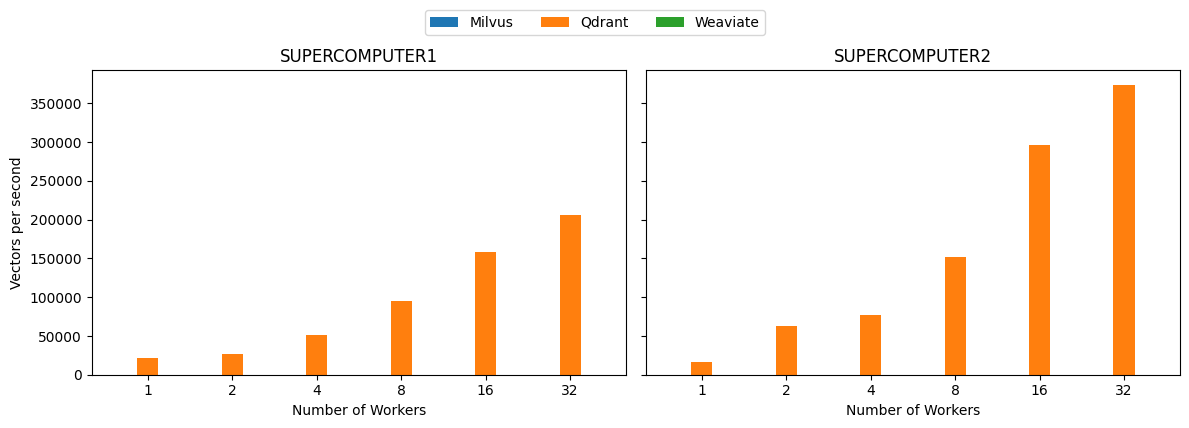

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# X-axis: number of workers
workers = [1, 2, 4, 8, 16, 32]
x = np.arange(len(workers))

bar_width = 0.25

# Placeholder data (replace later)
# SUPERCOMPUTER1
milvus_sc1   = [0, 0, 0, 0, 0, 0]
qdrant_sc1   = qdrantP2
weaviate_sc1 = [0, 0, 0, 0, 0, 0]

# SUPERCOMPUTER2
milvus_sc2   = [0, 0, 0, 0, 0, 0]
qdrant_sc2   = qdrantA
weaviate_sc2 = [0, 0, 0, 0, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

systems = [
    ("SUPERCOMPUTER1", milvus_sc1, qdrant_sc1, weaviate_sc1),
    ("SUPERCOMPUTER2", milvus_sc2, qdrant_sc2, weaviate_sc2),
]

for ax, (title, milvus, qdrant, weaviate) in zip(axes, systems):
    ax.bar(x - bar_width, milvus,   bar_width, label="Milvus")
    ax.bar(x,             qdrant,   bar_width, label="Qdrant")
    ax.bar(x + bar_width, weaviate, bar_width, label="Weaviate")

    ax.set_xticks(x)
    ax.set_xticklabels(workers)
    ax.set_xlabel("Number of Workers")
    ax.set_title(title)

axes[0].set_ylabel("Vectors per second")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.075))

plt.tight_layout()
plt.savefig("insertScaling.pdf", format="pdf", bbox_inches="tight")
plt.show()


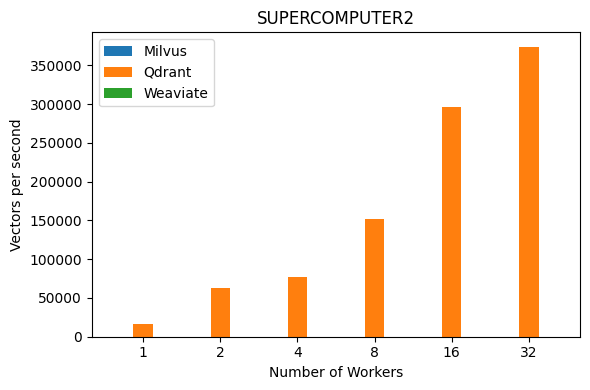

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# X-axis: number of workers
workers = [1, 2, 4, 8, 16, 32]
x = np.arange(len(workers))

bar_width = 0.25

# SUPERCOMPUTER2 data
milvus_sc2   = [0, 0, 0, 0, 0, 0]
qdrant_sc2   = qdrantA
weaviate_sc2 = [0, 0, 0, 0, 0, 0]

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(x - bar_width, milvus_sc2,   bar_width, label="Milvus")
ax.bar(x,             qdrant_sc2,   bar_width, label="Qdrant")
ax.bar(x + bar_width, weaviate_sc2, bar_width, label="Weaviate")

ax.set_xticks(x)
ax.set_xticklabels(workers)
ax.set_xlabel("Number of Workers")
ax.set_ylabel("Vectors per second")
ax.set_title("SUPERCOMPUTER2")

ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("insertScaling_supercomputer2.pdf", format="pdf", bbox_inches="tight")
plt.show()